In [1]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [2]:
df = pd.read_csv('results/clean_data/df_clean.csv')

X = df.drop('class_status', axis=1)
y = df['class_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
param_grid = {
    'n_estimators': [100, 200],      # число деревьев
    'learning_rate': [0.05, 0.1],    # шаг обучения (чем меньше нужно больше деревьев)
    'max_depth': [3, 4],             # глубина дерева (обычно 3-5)
    'subsample': [0.8, 1.0],         # доля выборки на каждое дерево
    'min_samples_split': [2, 5],     # мин. объектов для разбиения узла
    'max_features': ['sqrt', None]   # признаков при выборе сплита
}


In [5]:
model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', 
    n_jobs=1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END learning_rate=0.05, max_depth=3, max_features=sqrt, min_samples_split=2, n_estimators=100, subsample=1.0; total time=   0.3s


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 4], 'max_features': ['sqrt', None], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,loss,'log_loss'


In [7]:
result = pd.DataFrame(grid_search.cv_results_)
mean_train_score = result['mean_train_score'].mean()
mean_test_score = result['mean_test_score'].mean()

diff = mean_train_score - mean_test_score

if diff <= 0.05:
    print('Отлично')
elif diff > 0.05 and mean_train_score >= 0.90:
    print('Переобучение')
elif mean_train_score <= 0.70 and mean_test_score <= 0.70:
    print('Недообучение')
else:
    print('Модель нестабильна, стоит пересмотреть параметры')

Отлично


In [8]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [11]:
print('Метрики')
print(report)

Метрики
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1732
           1       0.97      0.97      0.97      1697

    accuracy                           0.97      3429
   macro avg       0.97      0.97      0.97      3429
weighted avg       0.97      0.97      0.97      3429



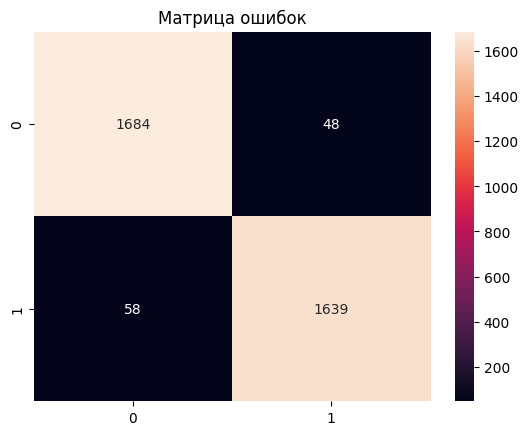

In [12]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Матрица ошибок')
plt.show()

In [13]:
joblib.dump(best_model, 'results/ml/result/gradient_boosting.pkl')
print('Модель сохранена')


Модель сохранена
